# Multimodal Wound Classification (ResNet50)

Final pipeline for wound classification using a ResNet50-based deep learning model.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Please replace the brackets below with the drive location of your folders which included subfolders for images
# Sample path: /content/drive/My Drive/ImageClassification
TRAINING_PATH = '/content/drive/MyDrive/1:1_Mouli_Banga/Wound Classification/Left_Leg/Train'
VALIDATION_PATH = '/content/drive/MyDrive/1:1_Mouli_Banga/Wound Classification/Left_Leg/Valid'

In [ ]:
def create_model(base_model, num_classes):
    import tensorflow as tf
    # Grab the last layer and add a few extra layers to it
    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    # Dense layer 1
    x=tf.keras.layers.Dense(100,activation='relu', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=True)(x)

    # Final layer with softmax activation
    preds=tf.keras.layers.Dense(num_classes,activation='softmax', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=False)(x)

    # Create the final model
    model=Model(inputs=base_model.input,outputs=preds)
    return model


In [ ]:
def get_optimizer(optimizer_name, learning_rate):
    # Import keras optimizers
    from tensorflow.keras.optimizers import Adam, Adadelta, Adagrad, Adamax, Ftrl, Nadam, RMSprop, SGD
    print('Selected Optimizer', optimizer_name)
    switcher = {
        'Adadelta': Adadelta(learning_rate=learning_rate),
        'Adagrad': Adagrad(learning_rate=learning_rate),
        'Adam': Adam(learning_rate=learning_rate),
        'Adamax': Adamax(learning_rate=learning_rate),
        'FTRL': Ftrl(learning_rate=learning_rate),
        'NAdam': Nadam(learning_rate=learning_rate),
        'RMSprop': RMSprop(learning_rate=learning_rate),
        'Gradient Descent': SGD(learning_rate=learning_rate)
    }
    # If optimizer_name is empty, Adam will be return as default optimizer
    return switcher.get(optimizer_name, Adam(learning_rate=learning_rate))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from keras.applications.resnet50 import preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,GlobalAveragePooling2D
from keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from keras.callbacks import EarlyStopping
from tensorflow import keras
# Initialize hyper params
epochs = 50 #<-- increase for higher accuracy
base_learning_rate = 0.05 #decrease for different results; use excel sheet to note down results from each change to learning rate and epochs
optimizer = 'Adam'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
# Create the data generation pipeline for training and validation
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_generator = train_datagen.flow_from_directory(TRAINING_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )
validation_generator = validation_datagen.flow_from_directory(VALIDATION_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )
print(validation_generator.class_indices.keys())
# Download the model
base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
for layer in base_model.layers:
    layer.trainable=False
# Specify the number of classes
num_classes = 5
# Create the base model
model = create_model(base_model,num_classes)
print(len(base_model.layers))
model.compile(optimizer = get_optimizer(optimizer_name=optimizer,learning_rate=base_learning_rate),loss='CategoricalCrossentropy',metrics=['accuracy'])
# Adam optimizer
# loss function will be categorical cross entropy
# evaluation metric will be accuracy
early_stopping_monitor = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=30,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)
step_size_train = train_generator.n//train_generator.batch_size
history_fine = model.fit(train_generator,
                        epochs=epochs,
                        validation_data = validation_generator,
                        verbose=1)

Found 271 images belonging to 5 classes.
Found 30 images belonging to 5 classes.
dict_keys(['D', 'N', 'P', 'S', 'V'])
175
Selected Optimizer Adam
Epoch 1/50
9/9 [==============================] - 72s 8s/step - loss: 49.7753 - accuracy: 0.2694 - val_loss: 11.3549 - val_accuracy: 0.6333
Epoch 2/50
9/9 [==============================] - 62s 7s/step - loss: 5.7178 - accuracy: 0.5830 - val_loss: 1.8830 - val_accuracy: 0.5333
Epoch 3/50
9/9 [==============================] - 62s 7s/step - loss: 1.3697 - accuracy: 0.5609 - val_loss: 1.1439 - val_accuracy: 0.5333
Epoch 4/50
9/9 [==============================] - 61s 7s/step - loss: 1.0475 - accuracy: 0.5793 - val_loss: 1.3140 - val_accuracy: 0.5667
Epoch 5/50
9/9 [==============================] - 67s 7s/step - loss: 0.8756 - accuracy: 0.6753 - val_loss: 1.2228 - val_accuracy: 0.6667
Epoch 6/50
9/9 [==============================] - 63s 7s/step - loss: 0.7785 - accuracy: 0.6716 - val_loss: 1.1037 - val_accuracy: 0.6333
Epoch 7/50
9/9 [========

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

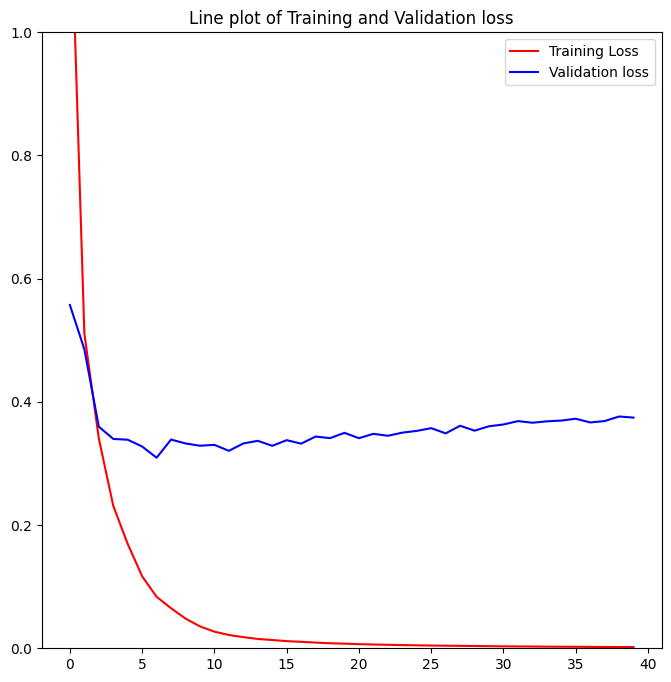

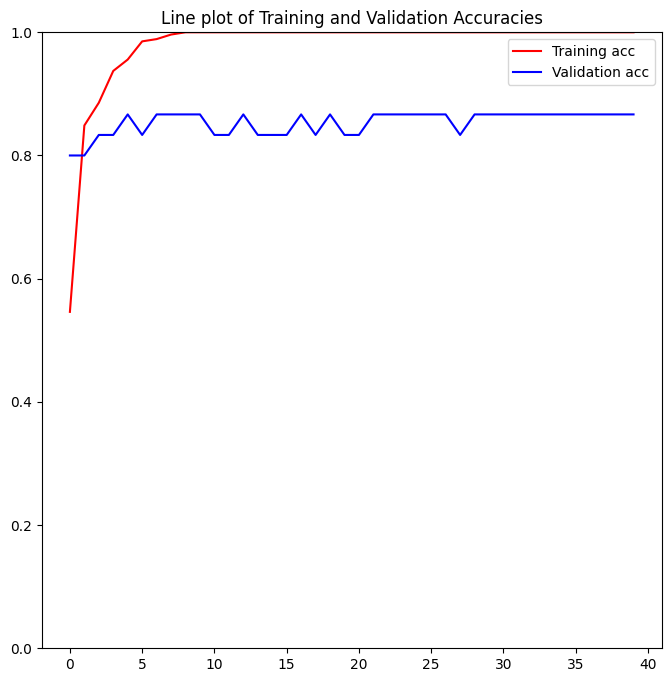

In [ ]:
def visualization():
    import pandas as pd
    df = pd.DataFrame(history_fine.history)
    #loss plots
    plt.figure(figsize=(8,8))
    plt.plot(df['loss'], color='red', label = "Training_loss")
    plt.plot(df['val_loss'], color='blue')
    plt.legend(['Training Loss','Validation loss'],loc = 'best' )
    plt.title('Line plot of Training and Validation loss')
    plt.ylim(0,1)
    plt.show()

    #accuracy plots
    plt.figure(figsize=(8,8))
    plt.plot(df['accuracy'], color='red')
    plt.plot(df['val_accuracy'], color='blue')
    plt.legend(['Training acc','Validation acc'],loc = 'best' )
    plt.title('Line plot of Training and Validation Accuracies')
    plt.ylim(0,1)
    plt.show()

visualization()

In [ ]:

# Import numpy for calculating best model accuracy
import numpy as np
# Populating matrics -> accuracy & loss
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

print('Training Accuracy: ', acc)
print('Validation Accuracy: ', val_acc)
print('Training Loss: ', loss)
print('Validation Loss: ', val_loss)
best_model_accuracy = history_fine.history['val_accuracy'][np.argmin(history_fine.history['val_loss'])]
print('best model accuracy: ', best_model_accuracy)


Training Accuracy:  [0.5461254715919495, 0.8487085103988647, 0.8856088519096375, 0.937269389629364, 0.955719530582428, 0.9852398633956909, 0.9889298677444458, 0.9963099360466003, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Validation Accuracy:  [0.800000011920929, 0.800000011920929, 0.8333333134651184, 0.8333333134651184, 0.8666666746139526, 0.8333333134651184, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8333333134651184, 0.8333333134651184, 0.8666666746139526, 0.8333333134651184, 0.8333333134651184, 0.8333333134651184, 0.8666666746139526, 0.8333333134651184, 0.8666666746139526, 0.8333333134651184, 0.8333333134651184, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8333333134651184, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 0.8666666746139526, 

In [ ]:
def seperate_labels(generator):
    x_validation = []
    y_validation = []
    num_seen = 0

    for x, labels in generator:
        x_validation.append(x)
        y_validation.append([argmax(label) for label in labels])
        num_seen += len(x)
        if num_seen == generator.n: break

    x_validation = np.concatenate(x_validation)
    y_validation = np.concatenate(y_validation)
    return x_validation, y_validation


In [ ]:

# Calculate and display the confusion matrix
import matplotlib.pyplot as plt
from numpy.core.fromnumeric import argmax
from sklearn.metrics import ConfusionMatrixDisplay

x_validation, y_validation = seperate_labels(validation_generator)
y_pred = model.predict(x_validation, batch_size=BATCH_SIZE)
predictions = np.apply_along_axis(argmax, 1, y_pred)
display_labels = validation_generator.class_indices.keys()

# ConfusionMatrixDisplay.from_predictions(y_validation, predictions, display_labels=display_labels, cmap="binary")
# plt.show()


1/1 [==============================] - 1s 992ms/step


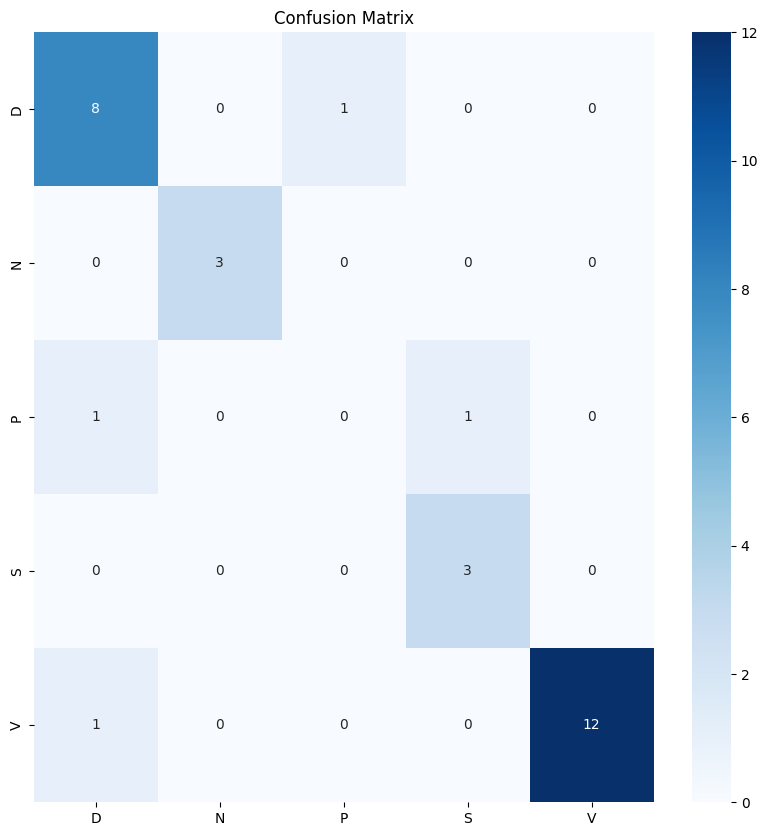

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
plt.figure(figsize = (10,10))
sns.heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'g', cmap = "Blues",xticklabels=display_labels, yticklabels=display_labels)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_validation, predictions))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         3
           4       1.00      0.92      0.96        13

    accuracy                           0.87        30
   macro avg       0.71      0.76      0.73        30
weighted avg       0.85      0.87      0.85        30



In [ ]:

# Predicting code for an image
from tensorflow.keras.preprocessing import image
# Please replace the brackets below with the location of your image which need to predict
img_path = '/content/drive/MyDrive/1:1_Mouli_Banga/Wound Classification/Left_Leg/Test/D/110_0.jpg'
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)
prediction = model.predict(img_preprocessed)
print(prediction)


1/1 [==============================] - 1s 832ms/step
[[9.9754298e-01 5.5364712e-06 2.3386437e-03 9.9335717e-05 1.3449989e-05]]


## Summary

ResNet50 achieved the best performance in this project, reaching approximately 90% accuracy.